In [1]:
from Bio.PDB import PDBParser, MMCIFParser, Superimposer
from scipy.spatial import distance
from pymol import cmd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import os
from Bio.PDB import PDBParser
import gzip
import shutil
import random

In [2]:
def get_first_atom_coordinates(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("structure", pdb_file)
    atom = [i for i in structure.get_atoms()][0]
    return atom.get_coord()

def get_alignment_matrix_in_pymol(path_ref, path_mob):
    cmd.reinitialize()
    cmd.load(path_ref, "ref")
    cmd.load(path_mob, "mob")   
    cmd.align("mob and name CA", "ref and name CA")
    matrix = cmd.get_object_matrix("mob")
    matrix = np.array(matrix).reshape(4, 4)
    return matrix

def transform_coordinate(matrix, coordinate):
    rotation = matrix[:3, :3]
    translation = matrix[:3, 3]
    transformed_coord = np.dot(rotation, coordinate) + translation
    return transformed_coord

In [3]:
# Define paths
root = "."
detected_pockets_dir = os.path.abspath(os.path.join(root, "..", "processed", "detected_pockets"))
raw_alphafill_dir = os.path.abspath(os.path.join(root, "..", "data", "structures", 'alphafill_database'))
aligned_dir = os.path.abspath(os.path.join(root, "..", "processed", "aligned_relaxed_structures"))

# Pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

# Get list of proteins
proteins = sorted(os.listdir(detected_pockets_dir))

In [4]:
### GET BACKGROUND POINTS ###

In [5]:
# Get all structures
sts = sorted(set(pocket_detection_data['File name'].apply(lambda x: x.replace(".pdb", ""))))

# Define some paths
PATH_TO_P2RANK = "/home/acomajuncosa/Documents/external_repos/p2rank_2.5/prank"
OUTDIR = os.path.join("..", "processed", 'alphafill_random')

# For each structure
for st in sts:

    # Get uniprot and create dir
    protein = st.split("_")[1]
    output = os.path.join(OUTDIR, st)
    os.makedirs(output, exist_ok=True)


    # Run P2Rank
    COMMAND = " ".join([PATH_TO_P2RANK, "predict", "-f", os.path.join(aligned_dir, protein, st + ".pdb"), 
                        "-o", output])
    os.system(COMMAND)

P2Rank 2.5



[INFO] Console - P2Rank 2.5
[INFO] Console - 
[INFO] Main - loading default config from [/home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/default.groovy]


DIR: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_data
DIR2: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_data
DIR: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_output
DIR2: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_output


[INFO] Console - DIR: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_data
[INFO] Console - DIR2: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_data
[INFO] Console - DIR: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_output
[INFO] Console - DIR2: /home/acomajuncosa/Documents/external_repos/p2rank_2.5/config/../test_output


predicting pockets for proteins from dataset [alphafold2_P9WFS9_model_0.pdb]


...

predicting pockets for proteins from dataset [swissmodel_P9WQA1_model_1.pdb]


[INFO] Console - predicting pockets for proteins from dataset [swissmodel_P9WQA1_model_1.pdb]
[INFO] PredictPocketsRoutine - outdir: ../processed/alphafill_random/swissmodel_P9WQA1_model_1
[INFO] Model - Loading model from directory (v3 format): /home/acomajuncosa/Documents/external_repos/p2rank_2.5/models/default
[INFO] FeatureSetup - enabledFeatures: [chem, volsite, protrusion, bfactor, atom_table]
[INFO] Dataset - processing dataset [swissmodel_P9WQA1_model_1.pdb] using 0 threads
[INFO] Dataset - 
------------------------------------------------------------------------------------------------------------------------
processing [swissmodel_P9WQA1_model_1.pdb] (1/1)
------------------------------------------------------------------------------------------------------------------------

[INFO] Console - processing [swissmodel_P9WQA1_model_1.pdb] (1/1)
[INFO] Protein - loading protein [/home/acomajuncosa/Documents/mtb-targeted-protein-degradation/processed/aligned_relaxed_structures/P9W

processing [swissmodel_P9WQA1_model_1.pdb] (1/1)


[INFO] Struct - all groups in chain A: 488
[INFO] Struct - all groups in chain A: 488
[INFO] Struct - 488 groups in chain A
[INFO] Protein - structure atoms: 7104
[INFO] Protein - protein   atoms: 3490
[INFO] Protein - ignoring ligands
[INFO] FeatureSetup - enabledFeatures: [chem, volsite, protrusion, bfactor, atom_table]
[INFO] Protein - SAS points: 5744
[INFO] Protein - exposed protein atoms: 2023 of 3490
[INFO] SLinkClusterer - clustering [124] elements
[INFO] SLinkClusterer - clusters: [id:2( 2 ), id:12( 3 ), id:39( 1 ), id:43( 1 ), id:45( 2 ), id:47( 16 ), id:52( 5 ), id:53( 2 ), id:54( 2 ), id:62( 13 ), id:65( 1 ), id:66( 1 ), id:69( 1 ), id:73( 2 ), id:82( 1 ), id:89( 2 ), id:91( 2 ), id:92( 6 ), id:96( 23 ), id:97( 1 ), id:98( 1 ), id:99( 1 ), id:101( 3 ), id:103( 3 ), id:108( 2 ), id:109( 4 ), id:111( 11 ), id:114( 1 ), id:115( 5 ), id:116( 1 ), id:123( 5 )]
[INFO] SLinkClusterer - clusters together: 124 / 124
[INFO] PocketPredictor - PREDICTING POCKETS.... ===================

predicting pockets finished in 0 hours 0 minutes 4.797 seconds
results saved to directory [/home/acomajuncosa/Documents/mtb-targeted-protein-degradation/processed/alphafill_random/swissmodel_P9WQA1_model_1]

Finished successfully in 0 hours 0 minutes 6.699 seconds.


In [7]:
points = {}

# Load points
for st in sts:

    # Decompress the gzipped file
    gz_path = os.path.join(OUTDIR, st, "visualizations", "data", f"{st}.pdb_points.pdb.gz")
    pdb_path = os.path.join(OUTDIR, st, "visualizations", "data", f"{st}.pdb_points.pdb")
    with gzip.open(gz_path, 'rb') as f_in:
        with open(pdb_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Read coordinates from the decompressed PDB file
    coords = []
    with open(pdb_path, 'r') as f:
        for line in f:
            if line.startswith("HETATM") or line.startswith("ATOM"):
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                coords.append([x, y, z])

    # Store coordinates in the dictionary
    points[st] = np.array(coords)

In [8]:
### GET MIN DISTANCES BETWEEN POCKETS AND ALPHAFILL LIGANDS ###

In [27]:
RESULTS = []

# For each protein
for c,protein in tqdm(enumerate(proteins)):

    random.seed(42)

    # Path to AlphaFill
    path_to_alphafill = os.path.join(raw_alphafill_dir, protein, f"{protein}.cif")

    # Get HETATM atoms
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("alphafill", path_to_alphafill)
    het_atoms = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if residue.id[0].startswith("H_"):
                    for atom in residue:
                        het_atoms.append(atom)

    # Get HETATM resiudes
    residues = set([i.get_parent().get_resname() for i in het_atoms])

    # Get all structures
    sts = sorted(os.listdir(os.path.join(aligned_dir, protein)))

    # For each structure
    for st in sts:

        # Get alignment matrix to AlphaFill structure
        path_to_st = os.path.join(aligned_dir, protein, st)
        matrix = get_alignment_matrix_in_pymol(path_to_alphafill, path_to_st)

        # For each detected pocket
        pockets = pocket_detection_data[pocket_detection_data['File name'] == st]['Pocket number'].tolist()
        for pocket in pockets:
            
            # Get path to pocket
            path_to_pocket = os.path.join(detected_pockets_dir, protein, st.replace('.pdb', ''), 'pockets', f"pocket_{pocket}.pdb")

            # Get 3D coordinate
            coord = get_first_atom_coordinates(path_to_pocket)

            # Apply transformation
            transformed_coord = transform_coordinate(matrix, coord)

            # Calculate distances against HETATMs
            distances = [[i.fullname, i.get_parent().get_resname(), round(distance.euclidean(i.get_coord(), transformed_coord), 3)] for i in het_atoms]
            distances = sorted(distances, key=lambda x: x[2])[0][1:]

            # Calculate distances against background points
            distances_random_per_pocket = []
            N = 10
            for n in range(N):
                random_index = random.randint(0, len(points[st.replace(".pdb", "")]) - 1)
                random_coord = points[st.replace(".pdb", "")][random_index]
                transformed_random_coord = transform_coordinate(matrix, random_coord)
                distances_random = [[i.fullname, i.get_parent().get_resname(), round(distance.euclidean(i.get_coord(), transformed_random_coord), 3)] for i in het_atoms]
                distances_random = sorted(distances_random, key=lambda x: x[2])[0][1:]
                distances_random_per_pocket.append(distances_random[1])


            RESULTS.append([protein, st.replace(".pdb", "", pocket), pocket] + distances + [",".join(map(str, sorted(distances_random_per_pocket)))])

            # Save transformed PDB
            # x, y, z = transformed_coord
            # with open(f"/home/acomajuncosa/Documents/tmp/pocket_{pocket}.pdb", "w") as pdb_file:
            #     pdb_file.write(f"HEADER    Pocket {pocket} Centroid\n")
            #     pdb_file.write(
            #         f"HETATM{pocket:5d} C   LIG A{pocket:4d}    "
            #         f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00          C\n"
            #     )
            #     pdb_file.write("END\n")

RESULTS = pd.DataFrame(RESULTS, columns=['protein', 'structure', 'pocket', 'AlphaFill closest ligand', 'distance', 'distances_random'])


5it [00:12,  2.31s/it]

 Executive-Detail: _struct_conn name lookup failed: AF/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AG/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AH/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AF/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AG/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AH/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AF/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AG/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AH/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AF/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AG/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AH/PYZ/1/N2/ W/NAD/0/C4N/
 Executive-Detail: _struct_conn name lookup failed: AF/PYZ/1/N2/

21it [00:52,  2.49s/it]


In [28]:
RESULTS['distances_random_mean'] = RESULTS['distances_random'].apply(lambda x: np.mean([float(i) for i in x.split(",")]))
RESULTS['distances_random_median'] = RESULTS['distances_random'].apply(lambda x: np.median([float(i) for i in x.split(",")]))
RESULTS['distances_random_min'] = RESULTS['distances_random'].apply(lambda x: np.min([float(i) for i in x.split(",")]))

In [ ]:
# RESULTS.to_csv("../processed/alphafill_annotations.csv", index=False)
# RESULTS = pd.read_csv("../processed/alphafill_annotations.csv")

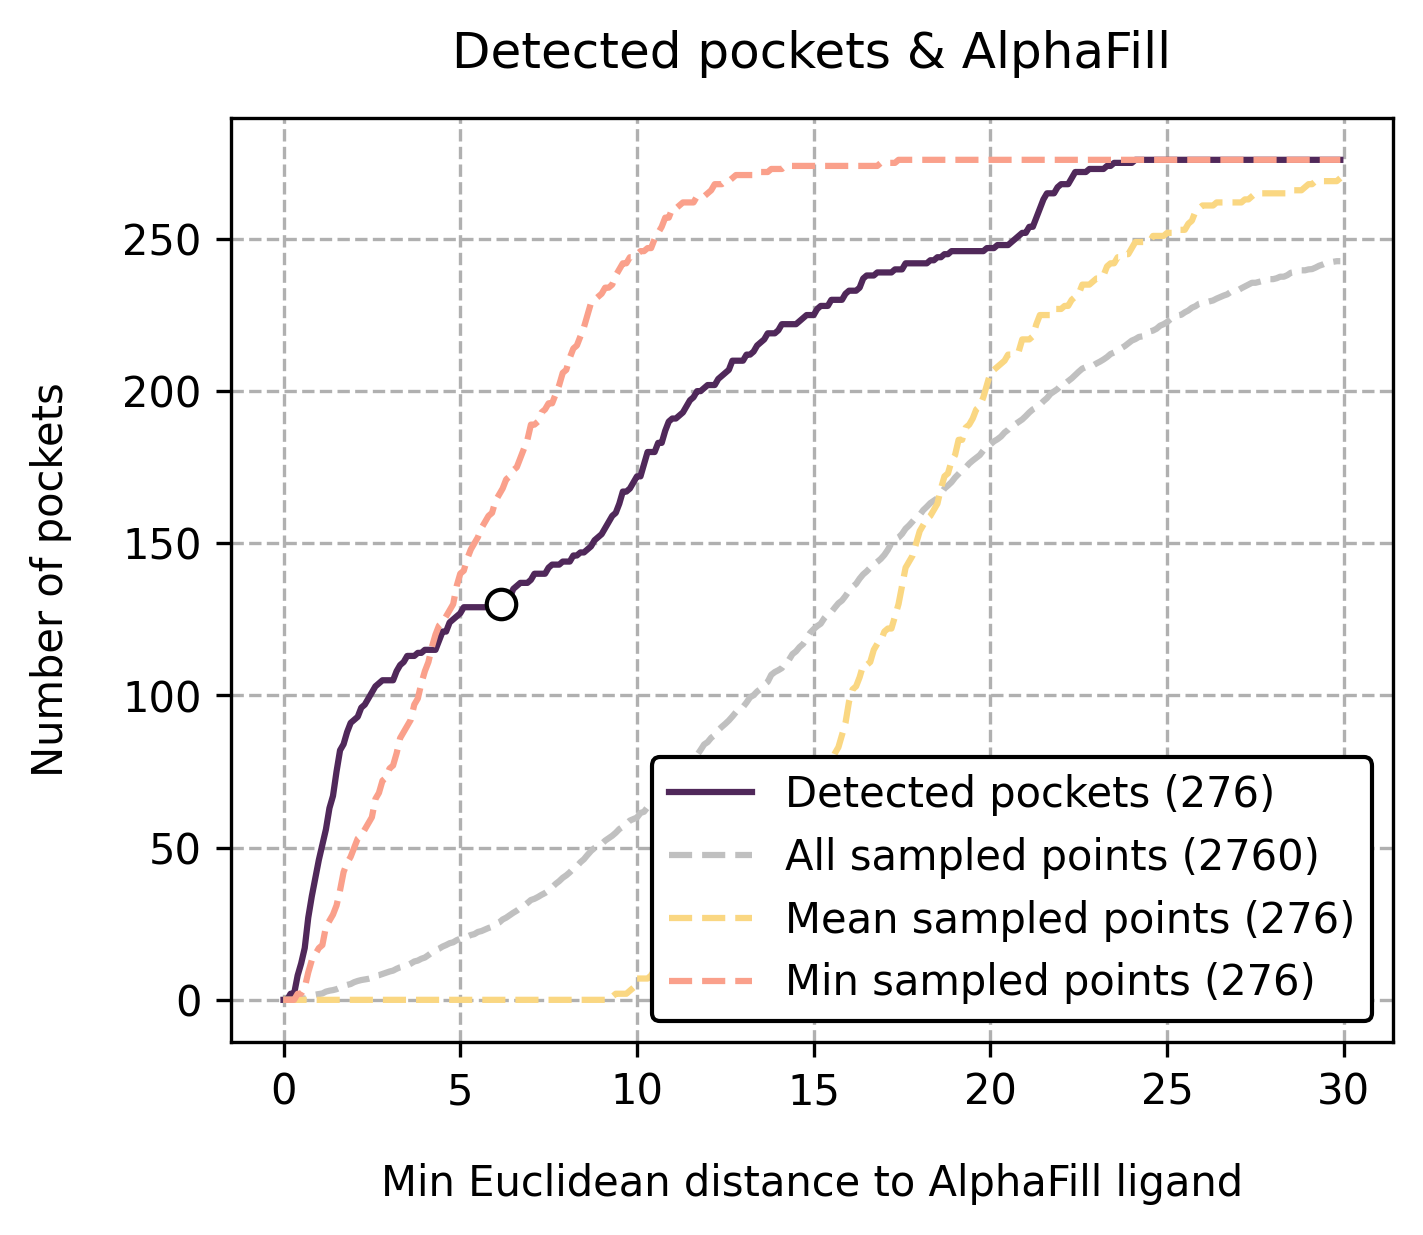

In [51]:
euclidean_distances = [i for i in np.arange(0, 30, 0.1)]

x = euclidean_distances
y = [len(RESULTS[RESULTS['distance'] <= i]) for i in euclidean_distances]

# Pocket detection
x_dot = 6.14
y_dot = len(RESULTS[RESULTS['distance'] <= x_dot])

# Background ALL
background_distances_ALL = np.array([float(j) for i in RESULTS['distances_random'].tolist() for j in i.split(",")])
y_background_ALL = [len(background_distances_ALL[background_distances_ALL <= i]) / N for i in euclidean_distances]

# Background MEAN
y_background_MEAN = [len(RESULTS[RESULTS['distances_random_mean'] <= i]) for i in euclidean_distances]

# Background MEAN
y_background_MIN = [len(RESULTS[RESULTS['distances_random_min'] <= i]) for i in euclidean_distances]


plt.figure(figsize=(5, 4))
plt.plot(x, y, c='#50285A', label=f'Detected pockets ({len(RESULTS)})')
plt.plot(x, y_background_ALL, c='silver', linestyle='--', label=f'All sampled points ({len(background_distances_ALL)})')
plt.plot(x, y_background_MEAN, c='#FAD782', linestyle='--', label=f'Mean sampled points ({len(RESULTS)})')
plt.plot(x, y_background_MIN, c='#FAA08B', linestyle='--', label=f'Min sampled points ({len(RESULTS)})')
plt.scatter(x_dot, y_dot, ec='k', s=50, c='w', zorder=3)
plt.title("Detected pockets & AlphaFill", pad=12)
plt.xlabel("Min Euclidean distance to AlphaFill ligand", labelpad=12)
plt.ylabel("Number of pockets", labelpad=12)
plt.grid(linestyle='--', zorder=-2)
plt.legend(framealpha=1, edgecolor='k')
plt.show()

In [52]:
# Remove alphafill_random generated files
shutil.rmtree(OUTDIR)